<ipython-input-5-f4255264ff86>:6: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000*np.exp(-t)
<ipython-input-5-f4255264ff86>:19: RuntimeWarning: invalid value encountered in double_scalars
  y_next = y_values[i] + h * f(t_values[i], y_values[i])


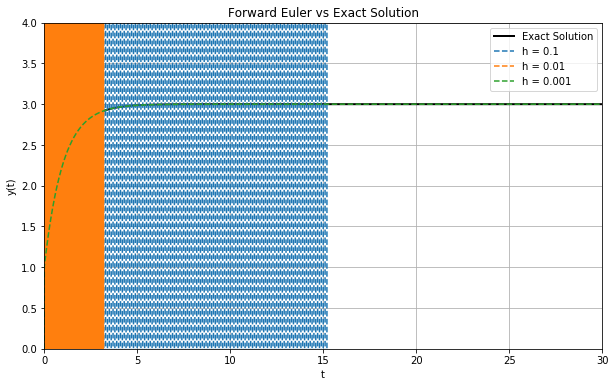

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ODE
def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

# exact solution
def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

# Forward Euler function
def forward_euler(f, y0, t0, tf, h, cutoff=1e6):
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values, dtype=float)
    y_values[0] = y0

    for i in range(len(t_values) - 1):
        y_next = y_values[i] + h * f(t_values[i], y_values[i])

        

        y_values[i+1] = y_next

    return t_values, y_values

# parameters
h_list = [0.1, 0.01, 0.001]
y0 = 0
t0 = 0
tf = 30

# exact curve
t_exact = np.linspace(t0, tf, 5000)
y_true = y_exact(t_exact)

# plot
plt.figure(figsize=(10,6))
plt.plot(t_exact, y_true, 'k', linewidth=2, label='Exact Solution')

for h in h_list:
    t_vals, y_vals = forward_euler(f, y0, t0, tf, h)
    plt.plot(t_vals, y_vals, '--', label=f'h = {h}')

plt.xlabel('t')
plt.ylabel('y(t)')
plt.title("Forward Euler vs Exact Solution")
plt.ylim(0, 4)
plt.xlim(0, 30)
plt.legend()
plt.grid(True)
plt.show()